1. Importation des dépendances (modules)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2. Génération des données

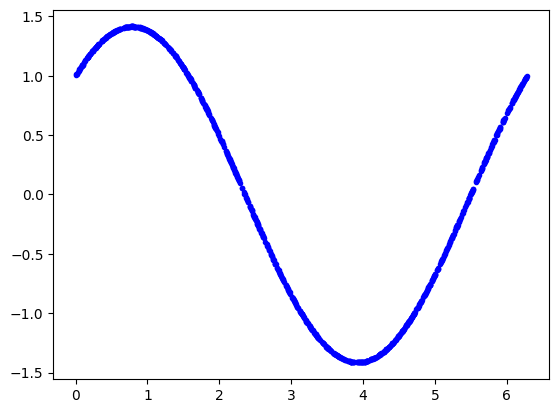

In [2]:
SAMPLES = 1000 # nombres d'échantillons considérés
SEED = 1337     # pour la reproductibilité de l'expérience

np.random.seed(SEED)
tf.random.set_seed(SEED)

x_values = np.random.uniform(low=0, high=2 * np.pi, size=SAMPLES)
np.random.shuffle(x_values) # Mélange aléatoirement les valeurs

y_values = np.sin(x_values) + np.cos(x_values)

plt.plot(x_values, y_values, "b.")
plt.show()

3. Ajout des bruits aux données

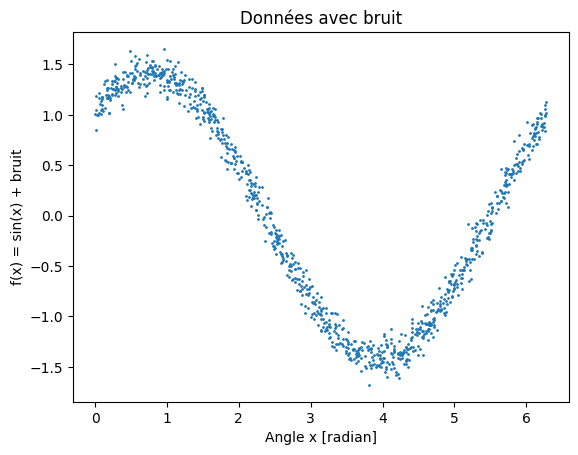

In [3]:
y_values += 0.1 * np.random.randn(*y_values.shape) # ajout d'un bruit gaussien

plt.scatter(x_values, y_values, s=1)
plt.xlabel("Angle x [radian]")
plt.ylabel("f(x) = sin(x) + bruit")
plt.title("Données avec bruit")
plt.show()

4. Division des données en trois ensembles (Entrainement, Validation et Test)

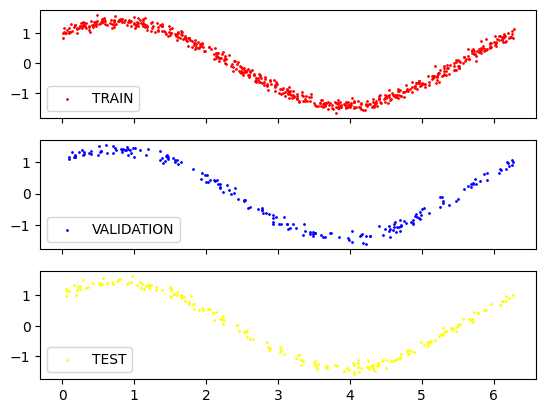

In [4]:
TRAIN_SPLIT = int(0.6 * SAMPLES)                # 60% des données
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)   # 20% des données

x_train, x_validate, x_test = np.split(x_values, (TRAIN_SPLIT, TEST_SPLIT))
y_train, y_validate, y_test = np.split(y_values, (TRAIN_SPLIT, TEST_SPLIT))

# vérification
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.scatter(x_train, y_train, c="red", s=1, label="TRAIN")
ax1.legend()
ax2.scatter(x_validate, y_validate, c="blue", s=1, label="VALIDATION")
ax2.legend()
ax3.scatter(x_test, y_test, c="yellow", s=1, label="TEST")
ax3.legend()
plt.show()

5. Modèle

In [5]:
model = tf.keras.Sequential([
    # Première couche
    tf.keras.layers.Dense(16, activation="relu", input_shape=(1,)),
    # Deuxième couche
    tf.keras.layers.Dense(16, activation="relu"),
    # Couche de sortie
    tf.keras.layers.Dense(1)
])
# ReLu(Rectified Linear Unit) ne laisse passer que les valeurs positives i.e. relu(x) = max(0, x)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
# rmsprop : algorithme d'optimisation adaptatif (ajuste le learning rate automatiquement)
# MSE (mean square error) : mesure la distance prédiction/réalité
# MAE (mean absolute error)
model.summary()

C:\Users\itel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

6. Entrainement du modèle

In [6]:
history = model.fit(x_train,
                    y_train,
                    epochs=600,
                    batch_size=16,
                    validation_data=(x_validate, y_validate)
                    )
# On traite 16 exemples à la fois avant de mettre à jour les poids
# 600 passages complets sur toutes les données d'entrainement
# Evalue sur les données de validation après chaque epoch

Epoch 1/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - loss: 0.8965 - mae: 0.8460 - val_loss: 0.8826 - val_mae: 0.8552
Epoch 2/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.7929 - mae: 0.8030 - val_loss: 0.7467 - val_mae: 0.7876
Epoch 3/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.7038 - mae: 0.7552 - val_loss: 0.6669 - val_mae: 0.7390
Epoch 4/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.6418 - mae: 0.7141 - val_loss: 0.6001 - val_mae: 0.6899
Epoch 5/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.5907 - mae: 0.6720 - val_loss: 0.5470 - val_mae: 0.6417
Epoch 6/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.5512 - mae: 0.6314 - val_loss: 0.5066 - val_mae: 0.5958
Epoch 7/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.5222 - mae: 0.5957 - val_loss: 0.4778 - val_mae: 0.5574
Epoch 8/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.5012 - mae: 0.5694 - val_loss: 0.4579 - val_mae: 0.5351
Epoch 9/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - 

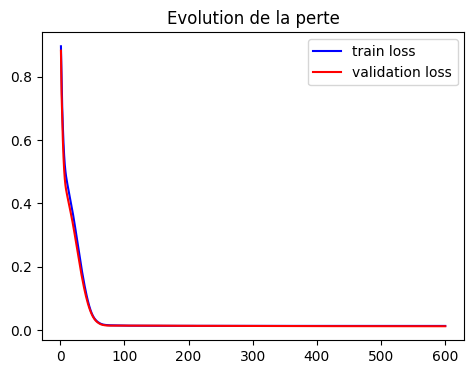

In [7]:
loss = history.history["loss"] # Récupère les valeurs "erreurs" à chaque epoch
val_loss = history.history["val_loss"] # Récupère les valeurs d'erreur de validation
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2,  1)
plt.plot(epochs, loss, "b", label="train loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.title("Evolution de la perte")
plt.show()

10. Test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0107 - mae: 0.0804
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


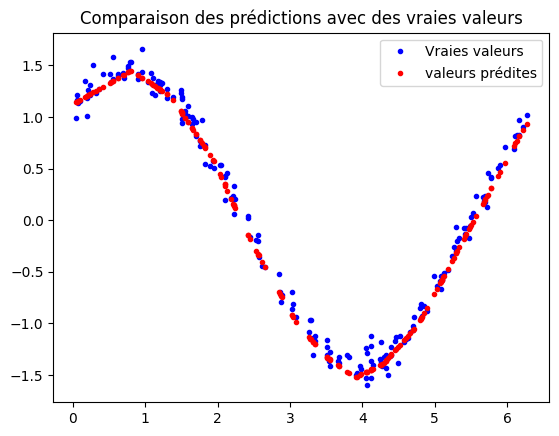

In [8]:
loss = model.evaluate(x_test, y_test)
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparaison des prédictions avec des vraies valeurs")
plt.plot(x_test, y_test, "b.", label="Vraies valeurs")
plt.plot(x_test, predictions, "r.", label="valeurs prédites")
plt.legend()
plt.show()

11. Conversion basique vers un modèle compressé

In [9]:
# Conversion simple sans quantification
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model=converter.convert()
print(f"Taille sans quantification {len(tflite_model)} octets")

INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpgtukre_g\assets


INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpgtukre_g\assets


Saved artifact at 'C:\Users\itel\AppData\Local\Temp\tmpgtukre_g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1806401707408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401709712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401711440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401706832: TensorSpec(shape=(), dtype=tf.resource, name=None)
Taille sans quantification 3164 octets


12. Conversion avec quantification

In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Fournir un dataset de calibration
def representative_dataset():
    for x in x_test[:100]:
        yield [np.array([x], dtype=np.float32).reshape(1,1)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32
tflite_model_q = converter.convert()

open("sine_model_quantized.tflite", "wb").write(tflite_model_q)
print(f"Taille quantifiée: {len(tflite_model_q)} octets")

INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpn76kh421\assets


INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpn76kh421\assets


Saved artifact at 'C:\Users\itel\AppData\Local\Temp\tmpn76kh421'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1806401707408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401710864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401709712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401707024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401711440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1806401706832: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\itel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Taille quantifiée: 3712 octets


13. Conversion en tableau C++

# Install xxd if it is not available
!apt-get -qq install xxd
# Save the file as a C source file
!xxd -i sine_model_quantized.tflite > sine_model_quantized.cc
# Print the source file
!cat sine_model_quantized.cc